In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [5]:
# Set your project folder path once
project_folder = r"C:\Users\sumed\OneDrive\Desktop\Extra_Projects\Telcom_customer_churn_ data\Telecom_Churn_Analysis"

# Load raw data
df_raw = pd.read_csv(os.path.join(project_folder, "Customer_Data.csv"))

# Create the SQLite database in the same folder
db_path = os.path.join(project_folder, "churn.db")
conn = sqlite3.connect(db_path)

# Push the raw dataframe into SQLite as a table called 'churn_data'
df_raw.to_sql("churn_data", conn, if_exists="replace", index=False)

print(f"Loaded {len(df_raw)} rows into SQLite table 'churn_data'")
print(f"Database created at: {db_path}")

Loaded 6418 rows into SQLite table 'churn_data'
Database created at: C:\Users\sumed\OneDrive\Desktop\Extra_Projects\Telcom_customer_churn_ data\Telecom_Churn_Analysis\churn.db


In [6]:
null_check_query = """
SELECT 
    SUM(CASE WHEN Value_Deal IS NULL THEN 1 ELSE 0 END) AS Value_Deal_Nulls,
    SUM(CASE WHEN Multiple_Lines IS NULL THEN 1 ELSE 0 END) AS Multiple_Lines_Nulls,
    SUM(CASE WHEN Internet_Type IS NULL THEN 1 ELSE 0 END) AS Internet_Type_Nulls,
    SUM(CASE WHEN Online_Security IS NULL THEN 1 ELSE 0 END) AS Online_Security_Nulls,
    SUM(CASE WHEN Online_Backup IS NULL THEN 1 ELSE 0 END) AS Online_Backup_Nulls,
    SUM(CASE WHEN Device_Protection_Plan IS NULL THEN 1 ELSE 0 END) AS Device_Protection_Nulls,
    SUM(CASE WHEN Premium_Support IS NULL THEN 1 ELSE 0 END) AS Premium_Support_Nulls,
    SUM(CASE WHEN Streaming_TV IS NULL THEN 1 ELSE 0 END) AS Streaming_TV_Nulls,
    SUM(CASE WHEN Streaming_Movies IS NULL THEN 1 ELSE 0 END) AS Streaming_Movies_Nulls,
    SUM(CASE WHEN Streaming_Music IS NULL THEN 1 ELSE 0 END) AS Streaming_Music_Nulls,
    SUM(CASE WHEN Unlimited_Data IS NULL THEN 1 ELSE 0 END) AS Unlimited_Data_Nulls
FROM churn_data;
"""

null_results = pd.read_sql(null_check_query, conn)
print(null_results)

   Value_Deal_Nulls  Multiple_Lines_Nulls  Internet_Type_Nulls  \
0              3548                   622                 1390   

   Online_Security_Nulls  Online_Backup_Nulls  Device_Protection_Nulls  \
0                   1390                 1390                     1390   

   Premium_Support_Nulls  Streaming_TV_Nulls  Streaming_Movies_Nulls  \
0                   1390                1390                    1390   

   Streaming_Music_Nulls  Unlimited_Data_Nulls  
0                   1390                  1390  


In [7]:
conn.execute("DROP TABLE IF EXISTS product_Churn")

cleaning_query = """
CREATE TABLE product_Churn AS
SELECT 
    Customer_ID, Gender, Age, Married, State, Number_of_Referrals, Tenure_in_Months,
    COALESCE(Value_Deal, 'None') AS Value_Deal,
    Phone_Service,
    COALESCE(Multiple_Lines, 'No') AS Multiple_Lines,
    Internet_Service,
    COALESCE(Internet_Type, 'None') AS Internet_Type,
    COALESCE(Online_Security, 'No') AS Online_Security,
    COALESCE(Online_Backup, 'No') AS Online_Backup,
    COALESCE(Device_Protection_Plan, 'No') AS Device_Protection_Plan,
    COALESCE(Premium_Support, 'No') AS Premium_Support,
    COALESCE(Streaming_TV, 'No') AS Streaming_TV,
    COALESCE(Streaming_Movies, 'No') AS Streaming_Movies,
    COALESCE(Streaming_Music, 'No') AS Streaming_Music,
    COALESCE(Unlimited_Data, 'No') AS Unlimited_Data,
    Contract, Paperless_Billing, Payment_Method,
    ABS(Monthly_Charge) AS Monthly_Charge,
    Total_Charges, Total_Refunds, Total_Extra_Data_Charges, Total_Long_Distance_Charges, Total_Revenue,
    Customer_Status,
    COALESCE(Churn_Category, 'Others') AS Churn_Category,
    COALESCE(Churn_Reason, 'Others') AS Churn_Reason
FROM churn_data;
"""

conn.execute(cleaning_query)
conn.commit()
print("product_Churn table created")

product_Churn table created


In [8]:
conn.execute("DROP VIEW IF EXISTS vw_ChurnData")
conn.execute("DROP VIEW IF EXISTS vw_JoinData")

conn.execute("""
CREATE VIEW vw_ChurnData AS
    SELECT * FROM product_Churn WHERE Customer_Status IN ('Churned', 'Stayed')
""")

conn.execute("""
CREATE VIEW vw_JoinData AS
    SELECT * FROM product_Churn WHERE Customer_Status = 'Joined'
""")

conn.commit()
print("Views created")

Views created


In [9]:
data = pd.read_sql("SELECT * FROM vw_ChurnData", conn)
print(data.shape)
print(data['Customer_Status'].value_counts())

(6007, 32)
Customer_Status
Stayed     4275
Churned    1732
Name: count, dtype: int64


In [10]:
# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# Binary columns (2 categories) - safe to label encode
binary_columns = [
    'Gender', 'Married', 'Phone_Service', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Paperless_Billing'
]

# Multi-category nominal columns - need one-hot encoding
nominal_columns = [
    'State', 'Value_Deal', 'Multiple_Lines', 'Internet_Service',
    'Internet_Type', 'Contract', 'Payment_Method'
]

# Label encode binary columns
label_encoders = {}
for column in binary_columns:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# One-hot encode nominal columns
data = pd.get_dummies(data, columns=nominal_columns, drop_first=True)

# Encode target variable
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split into features and target
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (4805, 56)
Test set shape: (1202, 56)


In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

print("Model trained")

Model trained


In [12]:
y_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.3f}")

Confusion Matrix:
[[808  47]
 [147 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.89       855
           1       0.81      0.58      0.67       347

    accuracy                           0.84      1202
   macro avg       0.83      0.76      0.78      1202
weighted avg       0.84      0.84      0.83      1202


ROC-AUC Score: 0.891


In [14]:
best = None
for p, r, t in zip(precisions, recalls, thresholds):
    if r < 0.75:
        break
    best = (p, r, t)

precision_at_best, recall_at_best, threshold_at_best = best
print(f"Threshold: {threshold_at_best:.3f} -> Precision: {precision_at_best:.3f}, Recall: {recall_at_best:.3f}")

Threshold: 0.350 -> Precision: 0.703, Recall: 0.758


In [15]:
# Apply the chosen threshold instead of default 0.5
y_pred_adjusted = (y_pred_proba >= threshold_at_best).astype(int)

print("Confusion Matrix (adjusted threshold):")
print(confusion_matrix(y_test, y_pred_adjusted))
print("\nClassification Report (adjusted threshold):")
print(classification_report(y_test, y_pred_adjusted))

Confusion Matrix (adjusted threshold):
[[744 111]
 [ 84 263]]

Classification Report (adjusted threshold):
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       855
           1       0.70      0.76      0.73       347

    accuracy                           0.84      1202
   macro avg       0.80      0.81      0.81      1202
weighted avg       0.84      0.84      0.84      1202



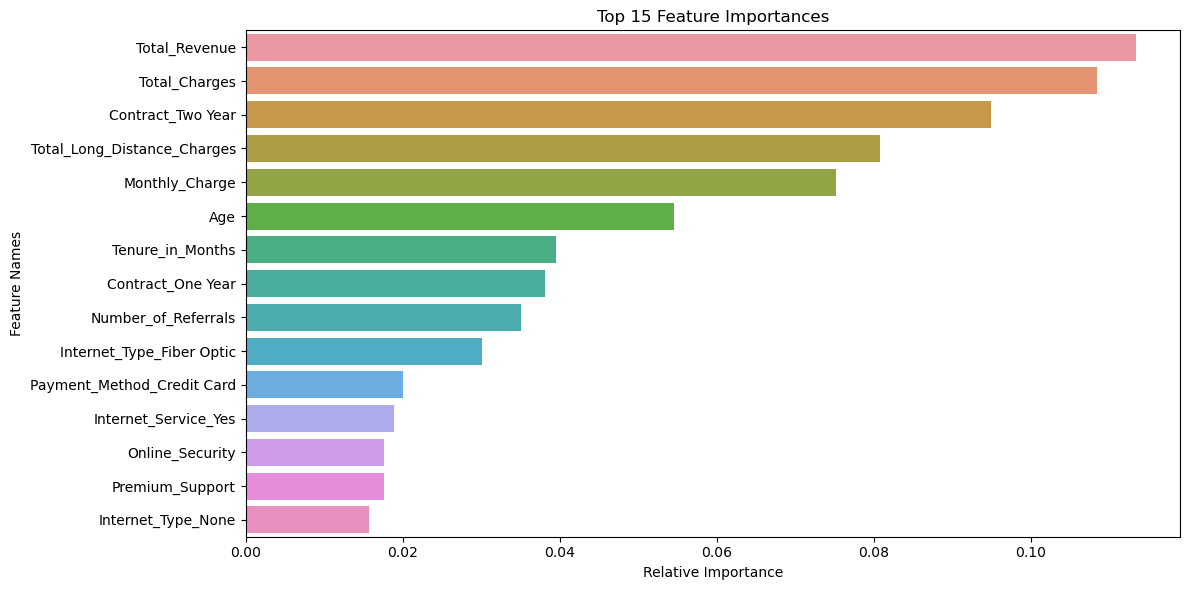

In [16]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15 features

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Top 15 Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.tight_layout()
plt.show()

In [17]:
# Drop the cumulative/leaky features and see if performance changes meaningfully
X_no_leak = X.drop(['Total_Revenue', 'Total_Charges'], axis=1)
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak, y, test_size=0.2, random_state=42, stratify=y
)

rf_check = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_check.fit(X_train_nl, y_train_nl)

y_pred_check = rf_check.predict(X_test_nl)
print(classification_report(y_test_nl, y_pred_check))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       855
           1       0.80      0.59      0.68       347

    accuracy                           0.84      1202
   macro avg       0.83      0.77      0.79      1202
weighted avg       0.84      0.84      0.83      1202



In [18]:
new_data_raw = pd.read_sql("SELECT * FROM vw_JoinData", conn)

original_data = new_data_raw.copy()
customer_ids = new_data_raw['Customer_ID']

new_data = new_data_raw.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)

# Apply same binary encoding
for column in binary_columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

# Apply same one-hot encoding
new_data = pd.get_dummies(new_data, columns=nominal_columns, drop_first=True)

# Align columns with training data (fills any missing dummy columns with 0)
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# Predict using probability + chosen threshold
new_proba = rf_model.predict_proba(new_data)[:, 1]
new_predictions = (new_proba >= threshold_at_best).astype(int)

original_data['Churn_Probability'] = new_proba
original_data['Customer_Status_Predicted'] = new_predictions

# Filter to just predicted churners
high_risk = original_data[original_data['Customer_Status_Predicted'] == 1].sort_values('Churn_Probability', ascending=False)

print(f"Predicted {len(high_risk)} customers as high churn risk out of {len(original_data)} total")
high_risk.head(10)

Predicted 393 customers as high churn risk out of 411 total


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason,Churn_Probability,Customer_Status_Predicted
57,78253-GUJ,Male,63,No,Gujarat,13,30,None,Yes,No,...,85.00,0.0,0,15.20,100.20,Joined,Others,Others,1.00,1
337,37131-MAH,Male,52,No,Maharashtra,6,2,None,Yes,No,...,89.25,0.0,0,16.64,105.89,Joined,Others,Others,1.00,1
208,96967-CHH,Female,33,No,Chhattisgarh,5,8,None,Yes,No,...,89.35,0.0,0,5.36,94.71,Joined,Others,Others,1.00,1
252,55043-UTT,Male,43,Yes,Uttar Pradesh,8,17,None,Yes,No,...,69.90,0.0,10,9.36,89.26,Joined,Others,Others,0.99,1
357,52641-JHA,Female,44,Yes,Jharkhand,7,29,None,Yes,No,...,71.10,0.0,0,37.51,108.61,Joined,Others,Others,0.99,1
272,83080-HAR,Female,54,No,Haryana,9,4,None,Yes,No,...,194.20,0.0,0,16.89,211.09,Joined,Others,Others,0.99,1
267,16032-AND,Female,47,No,Andhra Pradesh,8,18,None,Yes,No,...,87.90,0.0,0,3.74,91.64,Joined,Others,Others,0.99,1
294,38920-PUN,Female,50,No,Punjab,8,7,None,Yes,No,...,43.85,0.0,10,15.90,69.75,Joined,Others,Others,0.99,1
227,44700-DEL,Female,48,No,Delhi,10,19,Deal 5,Yes,Yes,...,84.60,0.0,0,7.34,91.94,Joined,Others,Others,0.99,1
201,82170-TAM,Male,41,No,Tamil Nadu,5,29,None,Yes,No,...,44.60,0.0,0,45.28,89.88,Joined,Others,Others,0.99,1


In [19]:
output_path = r"C:\Users\sumed\OneDrive\Desktop\Extra_Projects\Telcom_customer_churn_ data\Telecom_Churn_Analysis\Predicted_high_risk_customers.csv"
high_risk.to_csv(output_path, index=False)
print(f"Saved {len(high_risk)} high-risk customers to {output_path}")

conn.close()

Saved 393 high-risk customers to C:\Users\sumed\OneDrive\Desktop\Extra_Projects\Telcom_customer_churn_ data\Telecom_Churn_Analysis\Predicted_high_risk_customers.csv
